 # Object Detection using ResNet18 (Baseline Model)

As a baseline for our dangerous objects in luggage detection task, we will start by creating a simple object detection model using the ResNet18 architecture. This will allow us to establish a performance benchmark before we move on to more complex models and training pipelines.

 ## 1. Imports

In [ ]:
# this file ran using modal.com - the %uv magic commands are for installing packages in the modal environment.
%uv pip install ultralytics scikit-learn seaborn
%uv pip install opencv-python
%uv pip install kagglehub
%uv pip install torchmetrics[detection]

Using Python 3.12.6 environment at: /usr/local
Audited 3 packages in 16ms
Note: you may need to restart the kernel to use updated packages.
Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 6ms
Note: you may need to restart the kernel to use updated packages.
Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 8ms
Note: you may need to restart the kernel to use updated packages.
Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 7ms
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
import yaml
import shutil

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.transforms import ToTensor
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image
from torchmetrics.detection.mean_ap import MeanAveragePrecision

from tqdm.notebook import tqdm

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score
import seaborn as sns



 ## 2. Download and explore the dataset

We will first download the dataset from Kaggle and prepare it for training.

In [ ]:
# download the dataset
path = kagglehub.dataset_download("orvile/x-ray-baggage-anomaly-detection")
print("Path to dataset files:", path)

# set train, validation and test paths
train_path = os.path.join(path, "train")
val_path = os.path.join(path, "valid")
test_path = os.path.join(path, "test")

# print number of images and labels in the train path
num_train_images = len(os.listdir(os.path.join(train_path, "images")))
num_train_labels = len(os.listdir(os.path.join(train_path, "labels")))
print(f"Number of training images: {num_train_images}")
print(f"Number of training labels: {num_train_labels}")

Path to dataset files: /root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1
Number of training images: 6181
Number of training labels: 6181


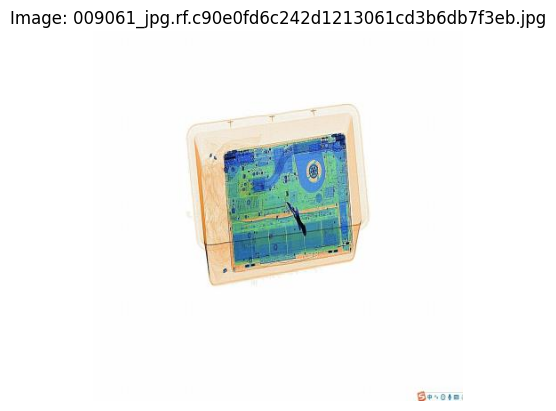

Contents of label file 009061_jpg.rf.c90e0fd6c242d1213061cd3b6db7f3eb.txt:
2 0.5576923076923077 0.515625 0.08052884615384616 0.13221153846153846


In [4]:
# select an image and its corresponding label file to inspect
image_file = os.listdir(os.path.join(train_path, "images"))[20]
label_file = image_file.replace(".jpg", ".txt")

# read the image
image = cv2.imread(os.path.join(train_path, "images", image_file))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# read the label file
with open(os.path.join(train_path, "labels", label_file), "r") as f:
    label_contents = f.read()

# plot the image
plt.imshow(image)
plt.title(f"Image: {image_file}")
plt.axis("off")
plt.show()

print(f"Contents of label file {label_file}:\n{label_contents}")



 Draw some some bounding boxes to understand the format of the labels and how to convert them to pixel coordinates.

In [5]:
def draw_yolo_bbox(image_path, label_data):
    # read image, convert to RGB and get dimensions
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W, _ = img.shape

    for line in label_data.splitlines():
        # take the label data and convert to float
        _, x, y, w, h = map(float, line.split())
        print(f"Label data - x: {x}, y: {y}, w: {w}, h: {h}")

        # compute the bounding box coordinates
        center_x, center_y = int(x * W), int(y * H)
        width, height = int(w * W), int(h * H)

        xmin = int(center_x - (width / 2))
        ymin = int(center_y - (height / 2))
        xmax = int(center_x + (width / 2))
        ymax = int(center_y + (height / 2))

        # draw the bounding box on the image
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title("Prohibited Objects")
    plt.axis('off')
    plt.show()



Label data - x: 0.5576923076923077, y: 0.515625, w: 0.08052884615384616, h: 0.13221153846153846


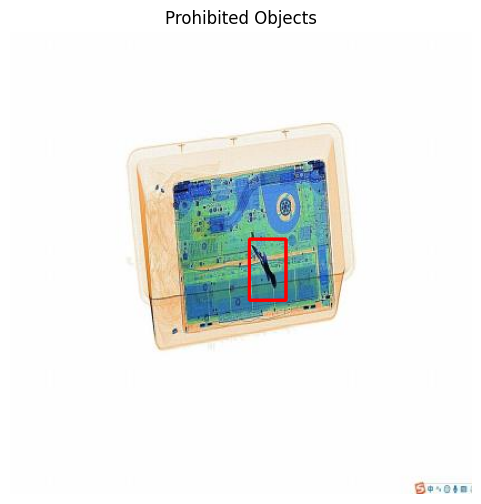

In [6]:
draw_yolo_bbox(os.path.join(train_path, "images", image_file), label_contents)


 ## 3. Image Preprocessing

 The preprocessing steps are as follows:

 1. Read the image in LAB color space.

 2. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to the L channel to enhance contrast.

 3. Convert the image back to RGB color space.

 4. Sharpen the image using a Gaussian blur and weighted addition.

 This preprocessing pipeline is designed to enhance the visibility of objects in the images and improve the performance of the object detection model.

In [ ]:
def preprocess_xray(img):
    # CLAHE (Contrast Limited Adaptive Histogram Equalization)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    img_clahe = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    # sharpening the image
    gaussian_blur = cv2.GaussianBlur(img_clahe, (9, 9), 10.0)
    img_sharp = cv2.addWeighted(img_clahe, 1.5, gaussian_blur, -0.5, 0)

    return img_sharp

 Apply all the preprocessing steps to every image in the dataset.

In [8]:
def apply_preprocessing_to_folder(src_path, dest_path):
    os.makedirs(dest_path, exist_ok=True)
    for img_name in os.listdir(src_path):
        img = cv2.imread(os.path.join(src_path, img_name))
        if img is not None:
            processed = preprocess_xray(img)
            cv2.imwrite(os.path.join(dest_path, img_name), processed)

# sabe in content - using colab
train_images_proc = "/content/dataset_processed/train/images"
val_images_proc = "/content/dataset_processed/valid/images"
test_images_proc = "/content/dataset_processed/test/images"

print("Preprocessing images...")
start_time = time.time()
apply_preprocessing_to_folder(os.path.join(train_path, "images"), train_images_proc)
apply_preprocessing_to_folder(os.path.join(val_path, "images"), val_images_proc)
apply_preprocessing_to_folder(os.path.join(test_path, "images"), test_images_proc)
end_time = time.time()
print(f"Preprocessing completed in {end_time - start_time:.2f} seconds")

Preprocessing images...
Preprocessing completed in 65.91 seconds


 ## 4. Create Dataset & DataLoader

The dataset class will read images and labels, and apply a standarization transformation to them based on the mean and standard deviation of the images in the training set. This will the convergence of the model during training.

In [9]:
def calculate_dataset_mean_and_std(folder_path):
    img_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

    if not img_files:
        raise ValueError(f"No images found in path: {folder_path}")

    to_tensor = ToTensor()

    # accumulators for R, G, B channels
    channels_sum = torch.zeros(3)
    channels_squared_sum = torch.zeros(3)
    total_pixels = 0

    for img_name in img_files:
        img_path = os.path.join(folder_path, img_name)
        img = Image.open(img_path).convert("RGB")
        tensor_img = to_tensor(img) # converts to [0.0, 1.0] range and (3, H, W) shape

        # track total pixels per image (H * W)
        num_pixels = tensor_img.size(1) * tensor_img.size(2)
        total_pixels += num_pixels

        # sum pixel values across height and width (dimensions 1 and 2)
        channels_sum += tensor_img.sum(dim=[1, 2])
        channels_squared_sum += (tensor_img ** 2).sum(dim=[1, 2])

    # statistical calculations
    dataset_mean = channels_sum / total_pixels
    dataset_std = torch.sqrt((channels_squared_sum / total_pixels) - (dataset_mean ** 2))

    # Convert to standard Python lists
    mean_list = dataset_mean.tolist()
    std_list = dataset_std.tolist()

    print(f"Calculation completed!")
    print(f"Calculated Mean for your X-Ray dataset: {mean_list}")
    print(f"Calculated Std for your X-Ray dataset:  {std_list}")

    return mean_list, std_list

# Compute global variables using your actual processed training images in Colab
XRAY_MEAN, XRAY_STD = calculate_dataset_mean_and_std(train_images_proc)

Calculation completed!
Calculated Mean for your X-Ray dataset: [0.8954328894615173, 0.879461407661438, 0.8448767066001892]
Calculated Std for your X-Ray dataset:  [0.21848894655704498, 0.22072364389896393, 0.2670595943927765]


In [ ]:
class XRayDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        # initialize the dataset with the directory paths and standarization transformations
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.image_files = sorted(os.listdir(images_dir))

        self.transform = transform or T.Compose([
            T.ToTensor(),
            T.Normalize(mean=XRAY_MEAN, std=XRAY_STD)
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # load the image and corresponding label file to return the image tensor, class label and bounding box coordinates
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = img_name.replace(".jpg", ".txt")
        label_path = os.path.join(self.labels_dir, label_name)

        class_id = 0
        bbox = [0.0, 0.0, 0.0, 0.0]

        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                lines = f.readlines()
                if lines:
                    data = lines[0].split()
                    class_id = int(data[0]) + 1
                    bbox = [float(x) for x in data[1:5]]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(class_id, dtype=torch.long), torch.tensor(bbox, dtype=torch.float32)



## 5. Baseline Model Architecture Using ResNet18 as Backbone

We now train a simple object detection model using the ResNet18 architecture as a backbone. The model consist on:
- A ResNet18 backbone for feature extraction.
- A custom head for bounding box regression and another one for classification.

In [11]:
class XRayBaselineModel(nn.Module):
    def __init__(self, num_classes):
        super(XRayBaselineModel, self).__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # classification head for background vs prohibited item
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

        # regression head for bounding box coordinates (x_center, y_center, width, height)
        self.box_regressor = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, 4),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.backbone(x)
        class_preds = self.classifier(features)
        bbox_preds = self.box_regressor(features)
        return class_preds, bbox_preds



 ## 6. Train and evaluate the model

In order to train the model, we use a combination of the CrossEntropyLoss for the classification head and the MSE loss for the bounding box regression head. They are combined in a single loss function as follows:

$$\text{Total Loss} = \text{Loss}_{\text{CrossEntropy}} + 2.0 \times \text{Loss}_{\text{MSE}}$$

Where the MSE loss is weighted by a factor of 2.0 to give it more importance during training. This is because accurate bounding box predictions are crucial for object detection performance, and we want to ensure that the model focuses on learning to predict bounding boxes effectively.

For the CrossEntropyLoss, we also asign class weight to handle class imbalance in the dataset, to differentiate the importance of the real objects vs the background class.

In [ ]:
def train_and_save_baseline(model, train_loader, val_loader, epochs=10, lr=0.001, device="cuda", weights_path="best_baseline.pth"):
    model = model.to(device)
    # add weigths to the classes diff from background
    pesos = torch.tensor([1.0, 2.5, 4.0, 4.0, 4.0, 5.0]).to(device)
    criterion_cls = nn.CrossEntropyLoss(weight=pesos)

    criterion_bbox = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    
    # initialize mAP metric for evaluation (configured for 'cxcywh' format, which represents the center coordinates, width, and height of the bounding boxes, and bounding box IoU type)
    map_metric = MeanAveragePrecision(box_format='cxcywh', iou_type='bbox')

    # save the training history for later visualization
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_map50": [], "val_map50": []
    }

    for epoch in range(epochs):
        print(f"\n--- Epoch {epoch+1}/{epochs} ---")

        # train the model
        model.train()
        train_loss = 0.0
        train_correct = 0
        map_metric.reset() # clear previous epoch's data for mAP calculation

        train_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
        for images, classes, bboxes in train_bar:
            images, classes, bboxes = images.to(device), classes.to(device), bboxes.to(device)

            optimizer.zero_grad()
            cls_preds, bbox_preds = model(images)

            loss_cls = criterion_cls(cls_preds, classes)
            mask = (classes > 0).float().unsqueeze(1)
            loss_bbox = criterion_bbox(bbox_preds * mask, bboxes * mask)

            total_loss = loss_cls + 2.0 * loss_bbox
            total_loss.backward()
            optimizer.step()

            train_loss += total_loss.item() * images.size(0)
            
            # classification accuracy calculation
            preds_class = cls_preds.argmax(dim=1)
            train_correct += (preds_class == classes).sum().item()

            # accumulate data for mAP (only batches where there are real or predicted objects)
            scores = torch.softmax(cls_preds, dim=1)
            for i in range(images.size(0)):
                # Structure required by torchmetrics
                preds_dict = [{
                    "boxes": bbox_preds[i].unsqueeze(0).cpu(),
                    "scores": scores[i].max().unsqueeze(0).cpu(),
                    "labels": preds_class[i].unsqueeze(0).cpu()
                }]
                target_dict = [{
                    "boxes": bboxes[i].unsqueeze(0).cpu(),
                    "labels": classes[i].unsqueeze(0).cpu()
                }]
                map_metric.update(preds_dict, target_dict)

            current_acc = (preds_class == classes).float().mean().item()
            train_bar.set_postfix(loss=total_loss.item(), acc=f"{current_acc:.2%}")

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)
        
        # compute mAP50 final of training for this epoch
        train_map_results = map_metric.compute()
        train_map50 = train_map_results["map_50"].item()

        # validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        map_metric.reset()

        val_bar = tqdm(val_loader, desc=f"Validating Epoch {epoch+1}", leave=False)
        with torch.no_grad():
            for images, classes, bboxes in val_bar:
                images, classes, bboxes = images.to(device), classes.to(device), bboxes.to(device)
                cls_preds, bbox_preds = model(images)

                loss_cls = criterion_cls(cls_preds, classes)
                mask = (classes > 0).float().unsqueeze(1)
                loss_bbox = criterion_bbox(bbox_preds * mask, bboxes * mask)

                total_loss = loss_cls + 2.0 * loss_bbox
                val_loss += total_loss.item() * images.size(0)
                
                preds_class = cls_preds.argmax(dim=1)
                val_correct += (preds_class == classes).sum().item()

                # accumulate data for mAP validation
                scores = torch.softmax(cls_preds, dim=1)
                for i in range(images.size(0)):
                    preds_dict = [{
                        "boxes": bbox_preds[i].unsqueeze(0).cpu(),
                        "scores": scores[i].max().unsqueeze(0).cpu(),
                        "labels": preds_class[i].unsqueeze(0).cpu()
                    }]
                    target_dict = [{
                        "boxes": bboxes[i].unsqueeze(0).cpu(),
                        "labels": classes[i].unsqueeze(0).cpu()
                    }]
                    map_metric.update(preds_dict, target_dict)

                current_val_acc = (preds_class == classes).float().mean().item()
                val_bar.set_postfix(loss=total_loss.item(), acc=f"{current_val_acc:.2%}")

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        
        # compute mAP50 final of validation for this epoch
        val_map_results = map_metric.compute()
        val_map50 = val_map_results["map_50"].item()
        
        # save everything in the history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_map50"].append(train_map50)
        history["val_map50"].append(val_map50)
        
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Loss (T/V): {train_loss:.4f} / {val_loss:.4f} | "
              f"Acc (T/V): {train_acc:.2%} / {val_acc:.2%} | "
              f"mAP50 (T/V): {train_map50:.4f} / {val_map50:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), weights_path)
            print(f"Saved new best model")

    print("\nTraining finished.")
    return history

This helper function will evaluate the model on the test set using the best weights obtained during training.

In [ ]:
def evaluate_on_test(model, test_loader, weights_path="best_baseline.pth", device="cuda"):
    if os.path.exists(weights_path):
        model.load_state_dict(torch.load(weights_path, map_location=device))
        print(f"Weights successfully loaded from '{weights_path}' for evaluation.\n")
    else:
        print(f"No weights found at '{weights_path}'. Evaluating with current weights.")

    model = model.to(device)
    model.eval()
    
    all_preds = []
    all_targets = []
    map_metric = MeanAveragePrecision(box_format='cxcywh', iou_type='bbox')
    
    with torch.no_grad():
        for images, classes, bboxes in test_loader:
            images = images.to(device)
            cls_preds, bbox_preds = model(images)
            preds = torch.argmax(cls_preds, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(classes.numpy())
            
            # accumulate data for mAP evaluation on test set
            scores = torch.softmax(cls_preds, dim=1)
            for i in range(images.size(0)):
                preds_dict = [{
                    "boxes": bbox_preds[i].unsqueeze(0).cpu(),
                    "scores": scores[i].max().unsqueeze(0).cpu(),
                    "labels": preds[i].unsqueeze(0).cpu()
                }]
                target_dict = [{
                    "boxes": bboxes[i].unsqueeze(0).cpu(),
                    "labels": classes[i].unsqueeze(0).cpu()
                }]
                map_metric.update(preds_dict, target_dict)
            
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    test_map_results = map_metric.compute()
    
    print("==================================================")
    print("         AVERAGE TEST MACRO METRICS")
    print("==================================================")
    print(f"Precisión General (Precision): {precision:.4f}")
    print(f"Sensibilidad General (Recall): {recall:.4f}")
    print(f"Detección Final mAP50 (Test): {test_map_results['map_50'].item():.4f}")
    print("==================================================\n")
    
    target_names = ['Background', 'Object 0', 'Object 1', 'Object 2', 'Object 3', 'Object 4'] 
    
    print("==================================================")
    print("            CLASSIFICATION REPORT              ")
    print("==================================================")
    # Busca esta línea dentro de evaluate_on_test y reemplázala por esta versión:
    print(classification_report(all_targets, all_preds, labels=range(len(target_names)), target_names=target_names, zero_division=0))

    print("==================================================")
    print("              CONFUSION MATRIX                 ")
    print("==================================================")
    cm = confusion_matrix(all_targets, all_preds)
    print(cm)
    print("==================================================")
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Matriz de Confusión - Baseline Test')
    plt.ylabel('Clase Real')
    plt.xlabel('Clase Predicha')
    plt.show()

    return all_targets, all_preds

Helper function to plot the training curves for loss and accuracy.

In [ ]:
def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(18, 5))
    
    # 1. Total Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], 'b-o', label='Train Loss', markersize=4)
    plt.plot(epochs, history["val_loss"], 'r-s', label='Val Loss', markersize=4)
    plt.title('Total Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    # 2. Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], 'b-o', label='Train Accuracy', markersize=4)
    plt.plot(epochs, history["val_acc"], 'r-s', label='Val Accuracy', markersize=4)
    plt.title('Classification Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # 3. mAP50
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["train_map50"], 'b-o', label='Train mAP50', markersize=4)
    plt.plot(epochs, history["val_map50"], 'r-s', label='Val mAP50', markersize=4)
    plt.title('Object Detection mAP @ IoU=0.50')
    plt.xlabel('Epochs')
    plt.ylabel('mAP50')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

 ## 7. Complete Execution

In [24]:
# instance pytorch datasets and dataloaders for training, validation and testing
train_dataset = XRayDataset(images_dir=train_images_proc, labels_dir=os.path.join(train_path, "labels"))
val_dataset = XRayDataset(images_dir=val_images_proc, labels_dir=os.path.join(val_path, "labels"))
test_dataset = XRayDataset(images_dir=test_images_proc, labels_dir=os.path.join(test_path, "labels"))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# configure the device for training and evaluation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current execution device: {device}")

# instance the model
model = XRayBaselineModel(num_classes=6)
print(model)

Current execution device: cuda
XRayBaselineModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1

In [25]:
# number of trainable params
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {trainable_params}")


Number of trainable parameters: 11309130



--- Epoch 1/10 ---


Training Epoch 1:   0%|          | 0/194 [00:00<?, ?it/s]

Validating Epoch 1:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch [1/10] | Loss (T/V): 1.6026 / 1.6105 | Acc (T/V): 22.41% / 22.65% | mAP50 (T/V): 0.0000 / 0.0000
Saved new best model

--- Epoch 2/10 ---


Training Epoch 2:   0%|          | 0/194 [00:00<?, ?it/s]

...

Validating Epoch 9:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch [9/10] | Loss (T/V): 1.5693 / 1.6328 | Acc (T/V): 23.28% / 22.37% | mAP50 (T/V): 0.0000 / 0.0000

--- Epoch 10/10 ---


Training Epoch 10:   0%|          | 0/194 [00:00<?, ?it/s]

Validating Epoch 10:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch [10/10] | Loss (T/V): 1.5674 / 1.6575 | Acc (T/V): 23.02% / 22.37% | mAP50 (T/V): 0.0000 / 0.0000

Training finished.


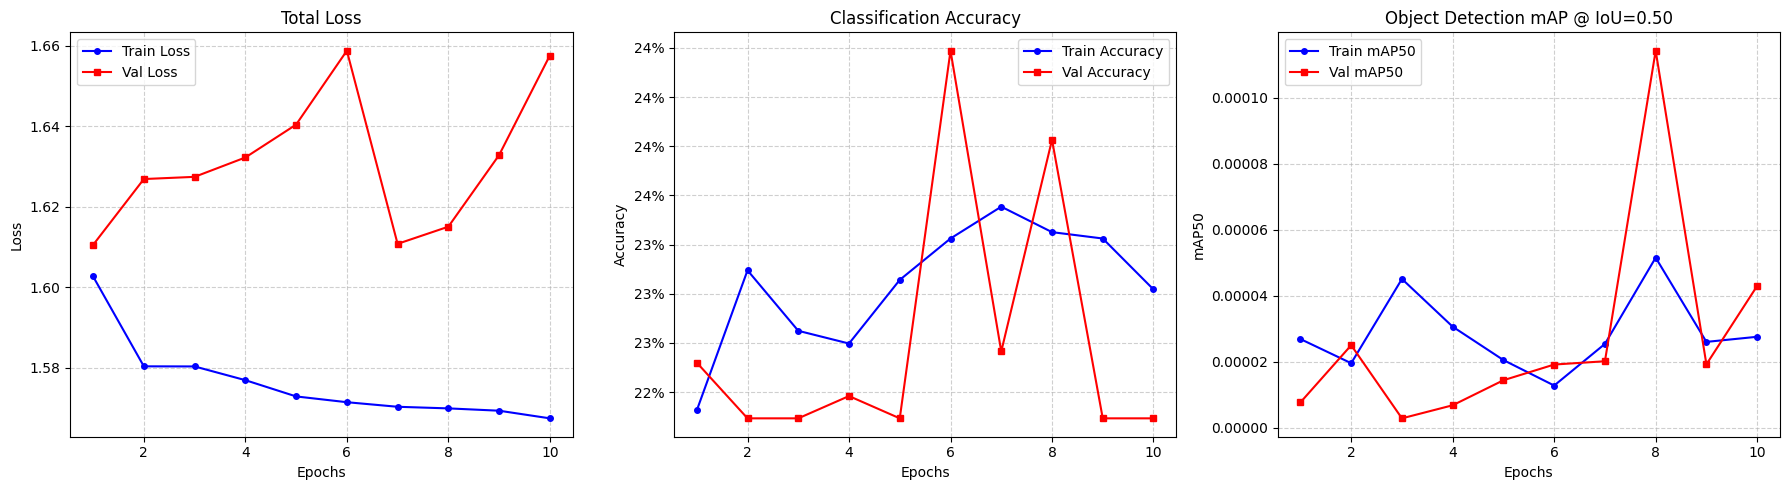

In [26]:
# train and save metrics history
metrics_history = train_and_save_baseline(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    epochs=10, 
    lr=0.001
)

# plot training curves
plot_training_curves(metrics_history)

Based on these training curves, the model is not really learning to detect the objects nor classify them correctly. The model might be too simple for the task.

Weights successfully loaded from 'best_baseline.pth' for evaluation.

         AVERAGE TEST MACRO METRICS
Precisión General (Precision): 0.1287
Sensibilidad General (Recall):    0.2163
Detección Final mAP50 (Test):     0.0000

            CLASSIFICATION REPORT              
              precision    recall  f1-score   support

  Background       0.00      0.00      0.00         0
    Object 0       0.00      0.00      0.00       166
    Object 1       0.22      0.95      0.36       193
    Object 2       0.00      0.00      0.00       118
    Object 3       0.00      0.00      0.00       203
    Object 4       0.42      0.13      0.20       203

    accuracy                           0.24       883
   macro avg       0.11      0.18      0.09       883
weighted avg       0.15      0.24      0.12       883

              CONFUSION MATRIX                 
[[  0 153   0   0  13]
 [  0 184   0   0   9]
 [  0 113   0   0   5]
 [  0 194   0   0   9]
 [  0 177   0   0  26]]


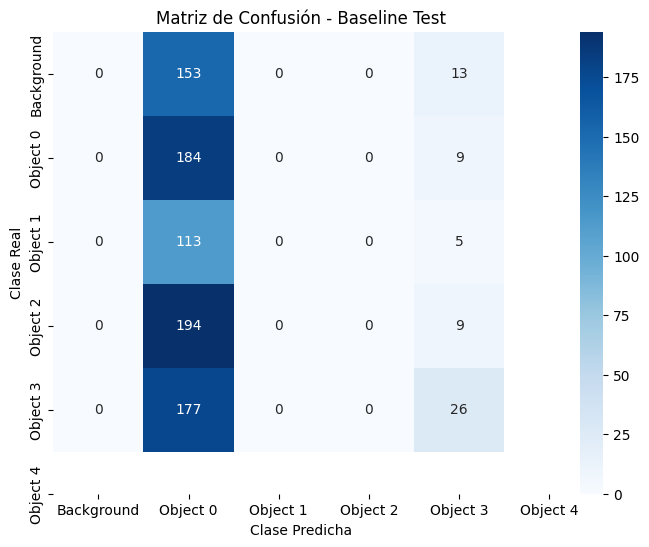

In [27]:
# run evaluation on test set using the best weights and print metrics
targets, preds = evaluate_on_test(model, test_loader, weights_path="best_baseline.pth", device=device)